# Exploratory Analysis 

In [1]:
import helpers as hp
import importlib, eda as de
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
importlib.reload(de)  

<module 'eda' from '/Users/berra/Desktop/bureau/EPFL/MA1/ML/project-1-ml212/eda.py'>

In [3]:
x_train, x_test, y_train, train_ids, test_ids = hp.load_csv_data("dataset")

### Inspect shapes

In [6]:
x_train.shape

(109379, 321)

In [5]:
y_train.shape

(328135,)

### Basic statistics

- For each feature (column in x_train): Min, max, mean, median, variance, proportion of missing values (if encoded as NaN or special value).
    - Constant or near-constant features (std ≈ 0, unique values = 1 or 2) ? -> don't provide useful infos
    - Feature scales and distributions ? -> Standardization/normalization will be needed before training
    - Categorical vs Continuous features ? Categorical may need one-hot encoding, numerical may need scaling
    - Outliers ? -> may need to clip or log-transform them

- Distribution histograms with matplotlib.

In [ ]:
de.dataset_overview(x_train, y_train)
stats = de.summarize_features(x_train)
de.print_feature_stats(stats)


Number of samples: 328135
Number of features: 321
Target distribution: (array([-1,  1]), array([299160,  28975]))
feat | min | max | mean | median | std | missing | unique
---------------------------------------------------------
   0 | 1.00 | 72.00 | 29.97 | 29.00 | 16.03 | 0 | 53
   1 | 1.00 | 12.00 | 6.36 | 6.00 | 3.49 | 0 | 12
   2 | 1012016.00 | 12312015.00 | 6563638.20 | 6242015.00 | 3489242.35 | 0 | 414
   3 | 1.00 | 12.00 | 6.42 | 6.00 | 3.49 | 0 | 12
   4 | 1.00 | 31.00 | 14.50 | 14.00 | 8.33 | 0 | 31


### Missing values

Features with no missing: 82
Features with some missing: 239
Max missing rate: 99.99%


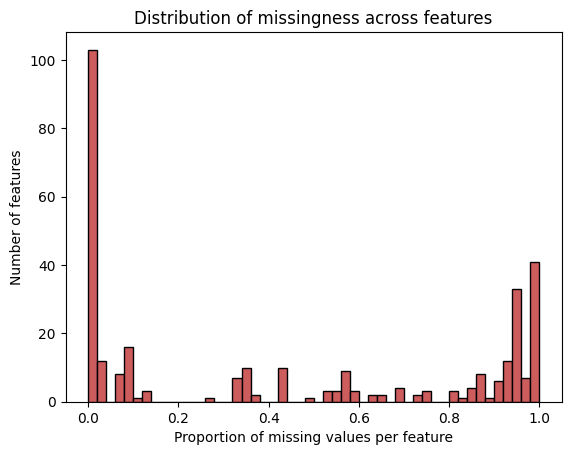


Missingness categories:
  0%–5%: 115 features
  5%–20%: 28 features
  20%–50%: 31 features
  50%–100%: 147 features


In [ ]:
perc_missing = de.analyze_missingness(x_train)

- 0-20% : Impute directly
- 20-50% : Keep if they look predictive and impute
- '>50%' : Should likely drop them

### y_train balance
First observation : y_train highly imbalanced

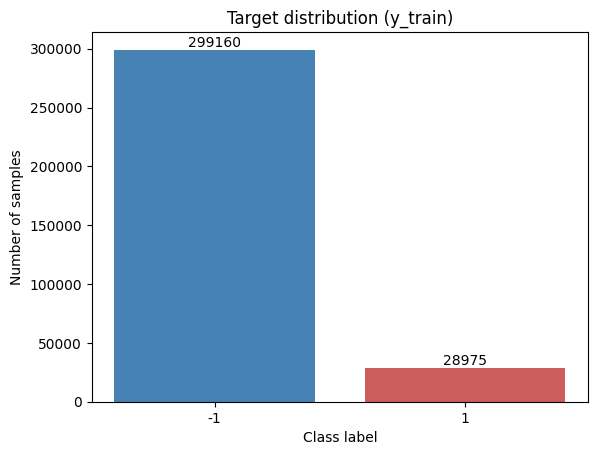

In [ ]:
de.plot_target_distribution(y_train)

Important to use other metrics during evaluation (e.g. F1-score). Preprocessing : duplication or deletion to achieve balanced y_train.

### Constant and near-constant features

In [ ]:
const_feats = de.find_constant_features(x_train)
print("Constant features:", const_feats)
print("Number of constant features:", len(const_feats))

Constant features: [9, 11, 12, 18, 19, 22]
Number of constant features: 6


In [ ]:
near_const_feats = de.find_near_constant_features(x_train)
print("Near-constant features:", near_const_feats)
print("Number of near-constant features:", len(near_const_feats))


Near-constant features: [280, 281]
Number of near-constant features: 2


Constant features can be dropped immediately during preprocessing. Near constant no, be careful.

In [ ]:
de.analyze_near_constant_features(x_train, y_train, near_const_feats)


Feature 280 (unique=2, most frequent=99.98%)
  value 0.0: count=70, positives=9 (12.86%)
  value 1.0: count=328065, positives=28966 (8.83%)

Feature 281 (unique=2, most frequent=99.99%)
  value 0.0: count=39, positives=3 (7.69%)
  value 1.0: count=328096, positives=28972 (8.83%)


We see that the most frequent is > 99.5%. More than likely that its not going to be useful to the model as it's clearly not correlated to the target. Can be dropped.

### Feature scales and distributions

Global min across features: 0.00
Global max across features: 2015023235.00
Median std across features: 1.37
Features with std < 1e-6: 6
Features with std > 1e3: 10


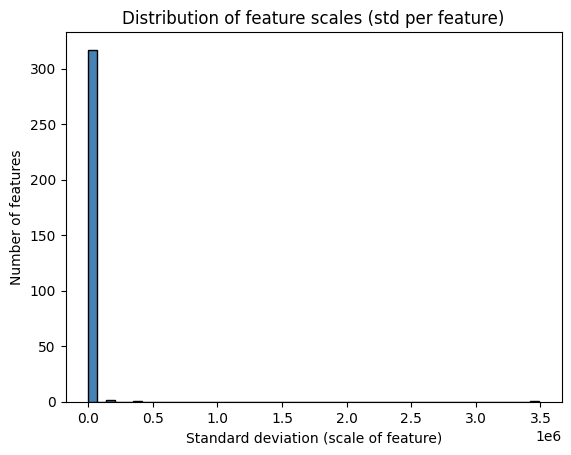

Features with std < 1e-6: [ 9 11 12 18 19 22]
Features with std > 1e3: [  2   7   8  62  63 101 105 219 226 264]


In [ ]:
mins, maxs, stds = de.feature_scale_summary(x_train)
de.plot_feature_stds(stds)
small, large = de.extreme_scale_features(stds)
print("Features with std < 1e-6:", small)
print("Features with std > 1e3:", large)



Distribution of feature scales : Shows that most features share a similar scale which is good.

Features with std < 1e-6: [ 9 11 12 18 19 22] == Constant features identified earlier. Will be dropped.

--> Analyze features with very large std


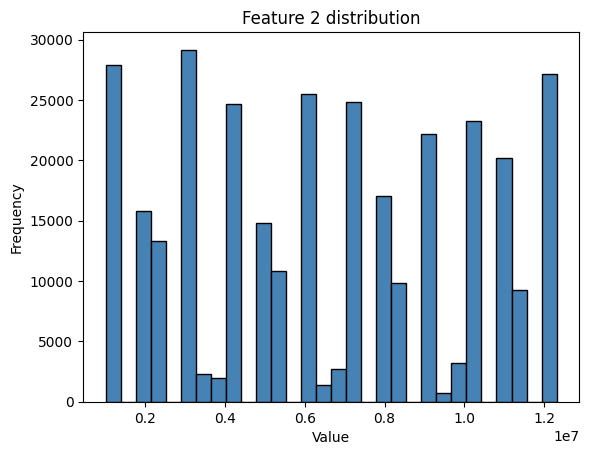

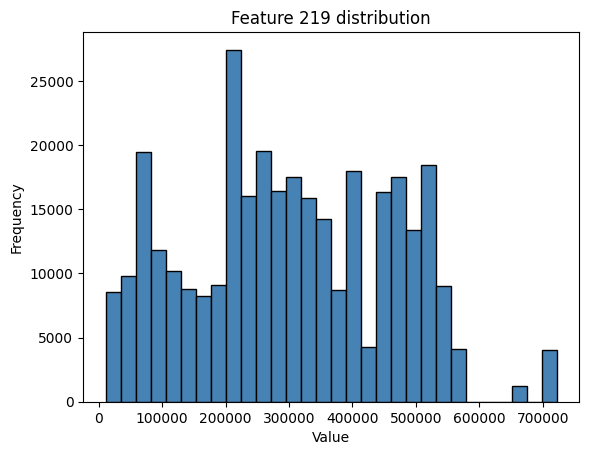

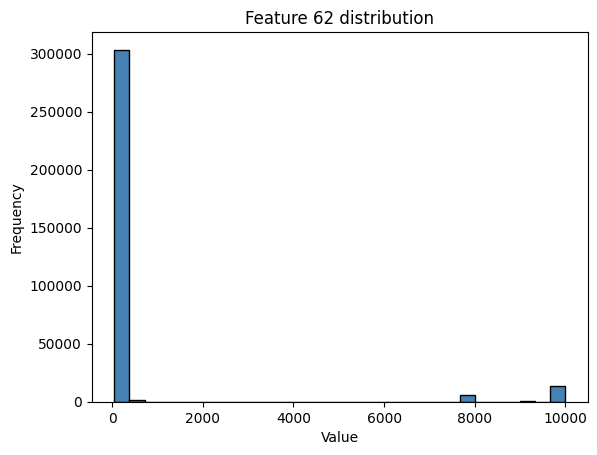

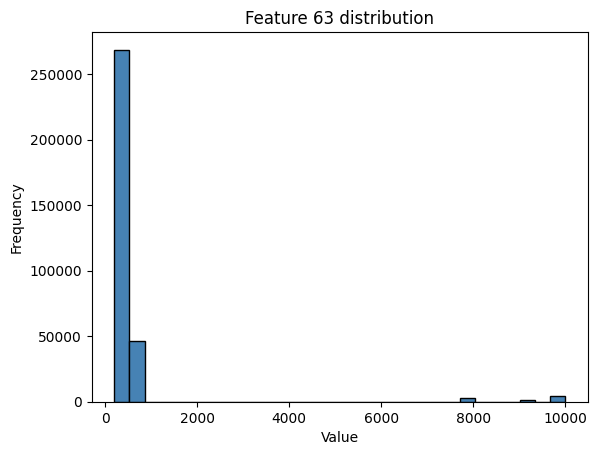

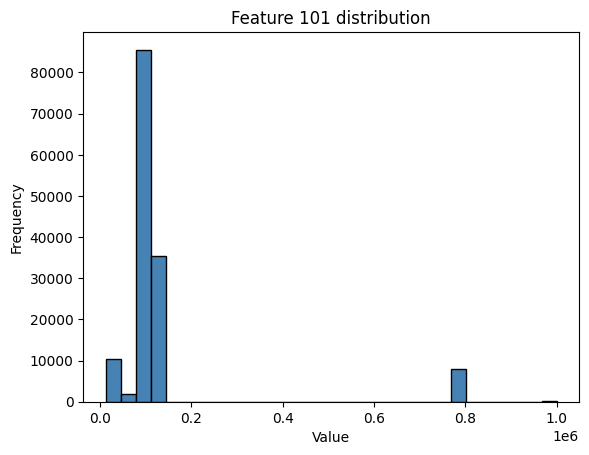

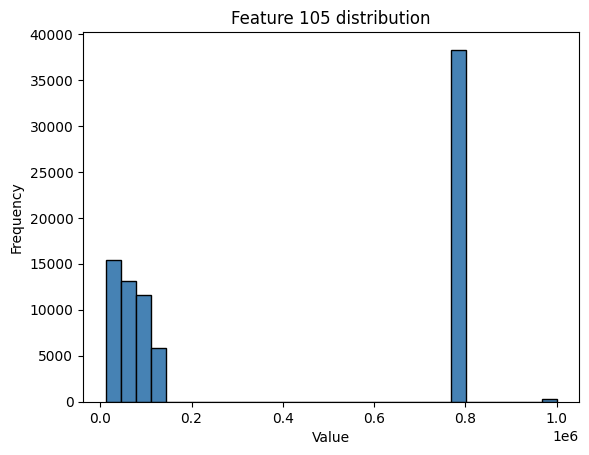

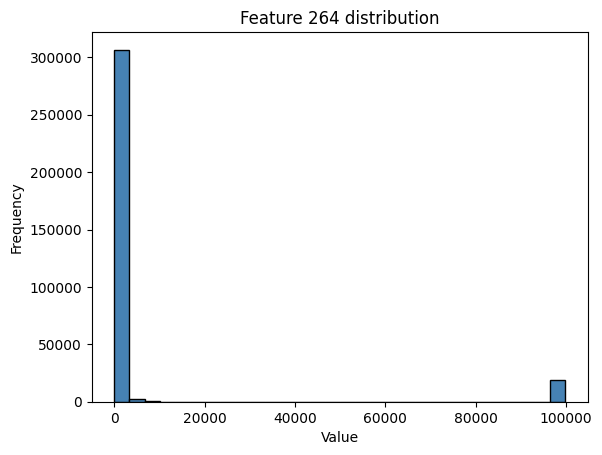

In [ ]:
de.plot_feature_distribution(x_train, 2)
de.plot_feature_distribution(x_train, 219)
de.plot_feature_distribution(x_train, 62)
de.plot_feature_distribution(x_train, 63)
de.plot_feature_distribution(x_train, 101)
de.plot_feature_distribution(x_train, 105)
de.plot_feature_distribution(x_train, 264)

### Analysis
# Features do not seem to be continuous. Could be IDs or code-like features. Need encoding as categorical.

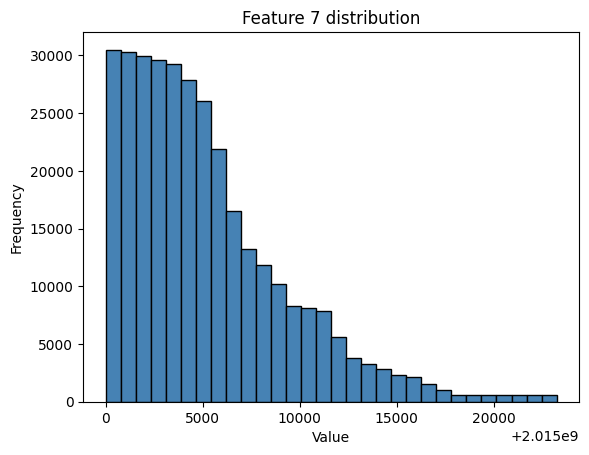

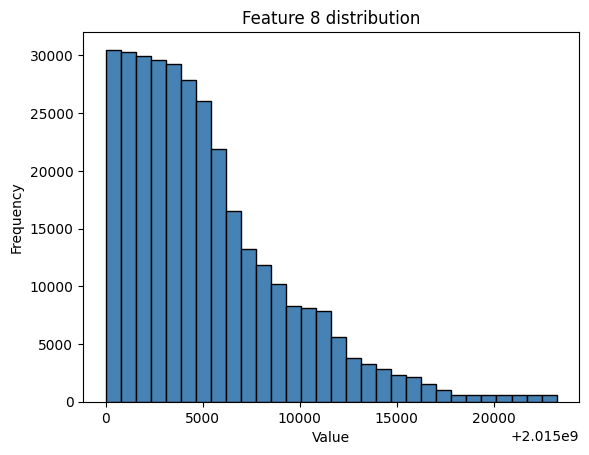

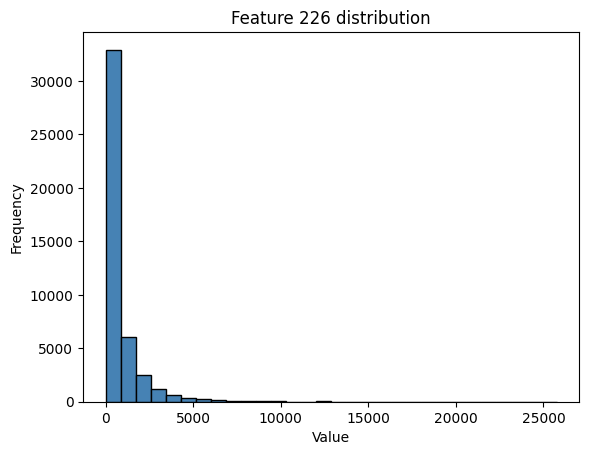

In [ ]:
de.plot_feature_distribution(x_train, 7)
de.plot_feature_distribution(x_train, 8)
de.plot_feature_distribution(x_train, 226)
### Analysis
# Feature 7 and 8 seem to be the same feature.
# All look like power law distribution. Try log-transforming them.

### Feature types

- Detect categorical vs continuous:
    - Continuous: many distinct numeric values, e.g. height, BMI.
    - Categorical: few distinct values, e.g. gender (0/1), yes/no responses.

- Plot frequency bar charts for categorical features.

In [ ]:
categorical, continuous = de.detect_feature_types(x_train)
print("Categorical features (example):", categorical[:20])
print("Continuous features (example):", continuous[:20])
print(f"Total categorical: {len(categorical)}, continuous: {len(continuous)}")

Categorical features (example): [0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Continuous features (example): [7, 8, 222, 226, 229, 253]
Total categorical: 315, continuous: 6


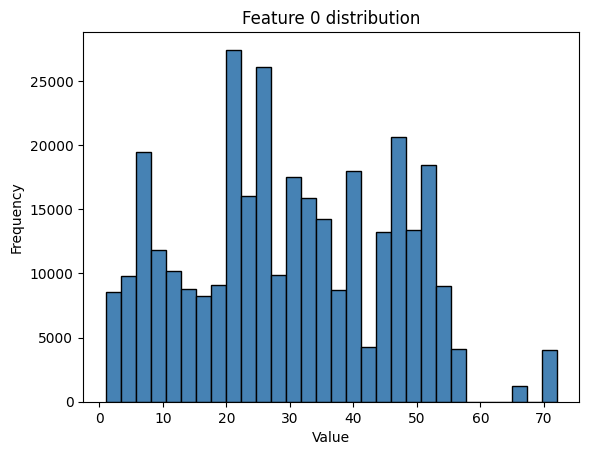

In [ ]:
de.plot_feature_distribution(x_train, 0)

### Correlation analysis

- Compute correlation (Pearson for continuous).

- Visualize with a heatmap to spot redundant features.

In [ ]:
#Compute correlation matrix for continuous features
features_to_check = [7, 8, 222, 226, 229, 253]
corr_matrix = de.compute_feature_correlation(x_train, features_to_check)
print(corr_matrix)

[[ 1.          1.          0.0903047  -0.03695394  0.05003009  0.057021  ]
 [ 1.          1.          0.0903047  -0.03695394  0.05003009  0.057021  ]
 [ 0.0903047   0.0903047   1.          0.29837661  0.72572913 -0.01402237]
 [-0.03695394 -0.03695394  0.29837661  1.          0.3049719  -0.00446365]
 [ 0.05003009  0.05003009  0.72572913  0.3049719   1.         -0.01588941]
 [ 0.057021    0.057021   -0.01402237 -0.00446365 -0.01588941  1.        ]]


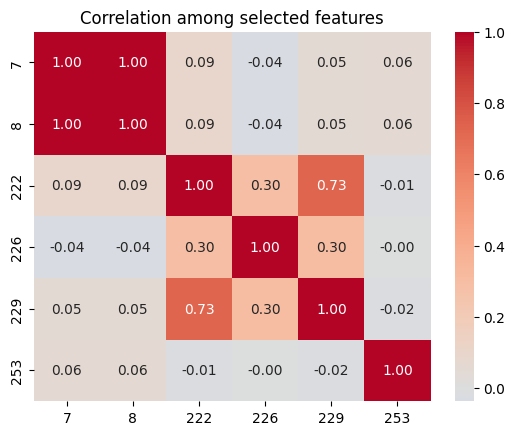

In [ ]:
#Visualize the correlation matrix with heatmap
sns.heatmap(corr_matrix, xticklabels=features_to_check, yticklabels=features_to_check,
            cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation among continuous features")
plt.show()


- Features 7 and 8 are the same feature as suspected before. Need to drop one.
- Features 222 and 229 are highly correlated but not enough to drop one for now. Could try to explore interaction?

# Data Cleaning & Feature Processing Pipeline

### Handle missing values

- If missing values exist:
    - For continuous: replace with mean/median.
    - For categorical: replace with mode or add “unknown” category.
    
- Document how many replacements you did.

### Remove or combine useless features

- Drop constant columns (variance = 0).

- Merge highly correlated/redundant features if appropriate.

### Standardize/normalize features

- Continuous features: subtract mean and divide by std ((x - mean)/std).

- This is crucial for gradient-based methods.

### Encode categorical features

- Binary encoding: already 0/1 (keep as is).
- Multi-category: one-hot encoding using NumPy.

Careful not to create too many features.

### Outlier handling (optional)
- Winsorization (clip extreme values).

Only if distributions show extreme anomalies.

### Feature engineering (optional for bonus)

- Combine existing features (e.g., BMI categories, interaction terms).

- Apply transformations (log for skewed distributions).